In [1]:
!date

Thu May 30 11:41:33 PDT 2024


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging
logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os
_os.chdir(_os.environ['PROJECT_ROOT'])

In [5]:
import graph_tool as gt
import graph_tool.draw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from contextlib import contextmanager
import xarray as xr
from itertools import product
from tqdm import tqdm
from itertools import chain
from graph_tool.util import find_edge
import scipy as sp

import strainzip as sz
from strainzip.pandas_util import idxwhere
import strainzip.app.deconvolve

from multiprocessing import Pool

In [72]:
%autoreload

In [6]:
group = 'xjin_test7'
dbg_type = 'denovo'

graph = sz.io.load_graph(f'data/group/{group}/r.proc.kmtricks-k111-m3-r2.ggcat-{dbg_type}.notips-2.smoothed.sz')
graph

<Graph object, directed, with 376226 vertices and 352830 edges, 4 internal vertex properties, 2 internal graph properties, edges filtered by (<EdgePropertyMap object with value type 'bool', for Graph 0x7ff34ab2cef0, at 0x7ff2f1a16f60>, 0), vertices filtered by (<VertexPropertyMap object with value type 'bool', for Graph 0x7ff34ab2cef0, at 0x7ff34ab742c0>, False), at 0x7ff34ab2cef0>

In [7]:
%%time
# NOTE: Only run this if you want to examine deconvolutions

with Pool(processes=22) as pool:
    flow = sz.app.deconvolve._run_estimate_all_flows(graph, mapping_func=pool.imap)

INFO:root:     (1) Optimize flow
100%|| 186/186 [03:18<00:00,  1.07s/it]
INFO:root:DONE (1) Optimize flow (219 sec)


CPU times: user 1min 25s, sys: 1min 9s, total: 2min 34s
Wall time: 3min 40s


array([2.15278281e-24, 1.78353352e-22, 1.22923228e-20, 7.04787609e-19,
       3.36166310e-17, 1.33389528e-15, 4.40312391e-14, 1.20912639e-12,
       2.76219362e-11, 5.24938174e-10, 8.29915390e-09, 1.09151850e-07,
       1.19426309e-06, 1.08702752e-05, 8.23100169e-05, 5.18485321e-04,
       2.71701391e-03, 1.18445586e-02, 4.29553759e-02, 1.29594863e-01,
       3.25259265e-01, 6.79114785e-01, 1.17958249e+00, 1.70445317e+00,
       2.04886550e+00, 2.04886550e+00, 1.70445317e+00, 1.17958249e+00,
       6.79114785e-01, 3.25259265e-01, 1.29594863e-01, 4.29553759e-02,
       1.18445586e-02, 2.71701391e-03, 5.18485321e-04, 8.23100169e-05,
       1.08702752e-05, 1.19426309e-06, 1.09151850e-07, 8.29915390e-09,
       5.24938174e-10, 2.76219362e-11, 1.20912639e-12, 4.40312391e-14,
       1.33389528e-15, 3.36166310e-17, 7.04787609e-19, 1.22923228e-20,
       1.78353352e-22, 2.15278281e-24])

<class 'strainzip.depth_model._normal.NormalDepthModel'> {}
2 x 2

-1155.9978 PathSet(paths=frozenset({LocalPath(left=1, right=1), LocalPath(left=0, right=0)}), n=2, m=2)
-3436.4736 PathSet(paths=frozenset({LocalPath(left=0, right=1), LocalPath(left=1, right=0)}), n=2, m=2)
-4650.7314 PathSet(paths=frozenset(), n=2, m=2)
excess_paths: 0
completeness_ratio: 1.0
max_relative_stderr: 0.33543608


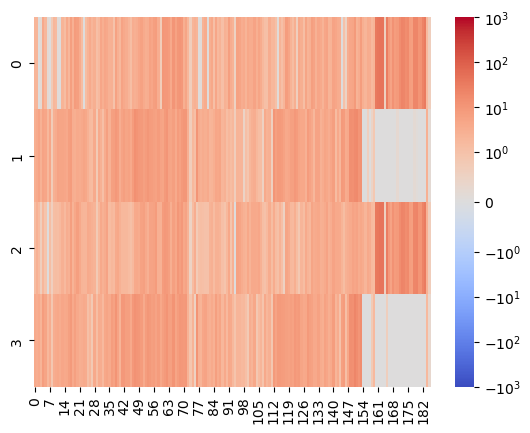

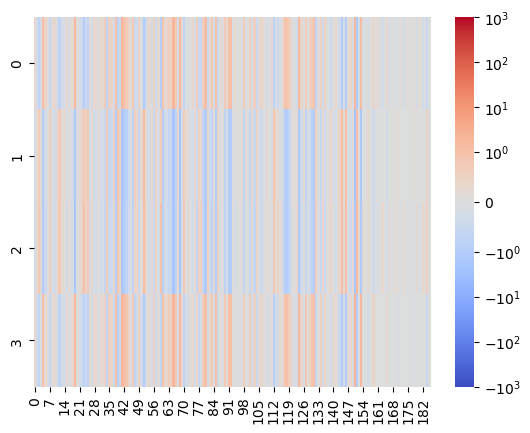

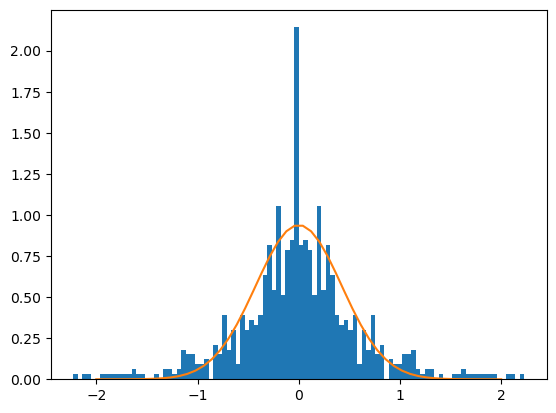

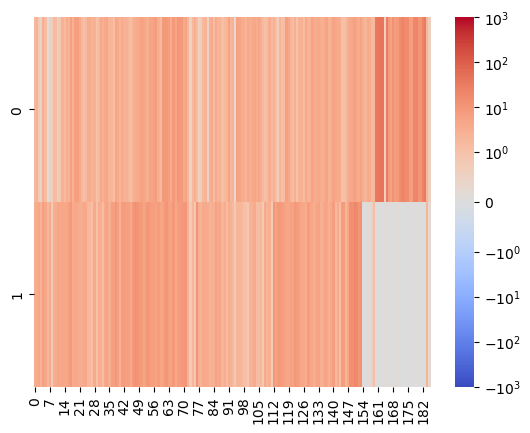

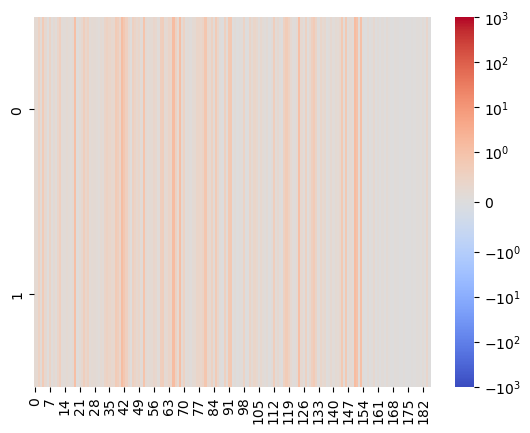

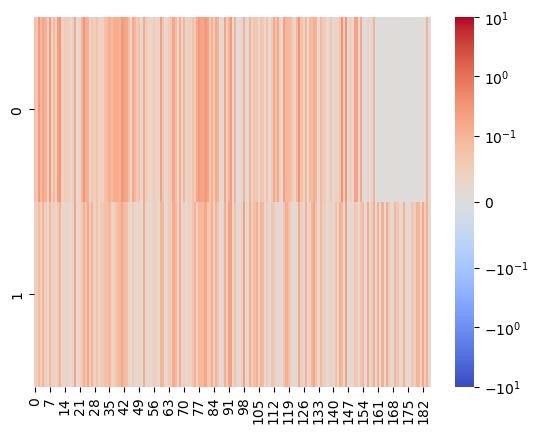

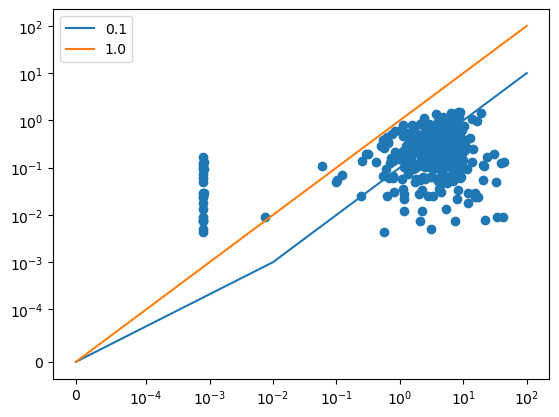

In [112]:
j = 15 # 11 # 4  # 11
model_name = 'Normal'

_, in_neighbors, in_flows, out_neighbors, out_flows = list(
    sz.app.deconvolve._iter_junction_deconvolution_data(
        [j], graph, flow, max_paths=1000
    )
)[0]

depth_model_class, depth_model_params = sz.depth_model.NAMED_DEPTH_MODELS[model_name]
print(depth_model_class, depth_model_params)


n, m = len(in_neighbors), len(out_neighbors)
print(f"{n} x {m}")
print()

fit, paths, named_paths, score_margin = sz.deconvolution.deconvolve_junction(
    in_neighbors,
    in_flows,
    out_neighbors,
    out_flows,
    depth_model_class(**depth_model_params, maxiter=10000),
    score_name='aic',
    verbose=True,
)

X, _ = sz.deconvolution.design_all_paths(n, m)
y = np.concatenate([in_flows, out_flows])

# X, y, labels = sz.deconvolution.formulate_path_deconvolution(in_flows, out_flows)

fig = plt.figure()
sns.heatmap(fit.y, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap(fit.residual, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
plt.hist(fit.residual.flatten(), density=True, bins=100)
plt.plot(np.linspace(-2, 2), sp.stats.norm(loc=0, scale=fit.params['sigma'].mean()).pdf(np.linspace(-2, 2)))

fig = plt.figure()
sns.heatmap(fit.beta, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap(fit.stderr_beta, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap((fit.stderr_beta) / (fit.beta + 1), norm=mpl.colors.SymLogNorm(1e-1, vmin=-1e1, vmax=1e1), cmap='coolwarm')

fig = plt.figure()
plt.scatter(fit.beta, fit.stderr_beta)
xx = np.concatenate([[0], np.logspace(-2, 2)])
plt.plot(xx, xx * 0.1, label=0.1)
plt.plot(xx, xx, label=1.0)
plt.legend()
# plt.plot(xx, (xx + 1) * 0.1)
# plt.plot(xx, (xx + 1) * 0.5)
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('symlog', linthresh=1e-4)

print('excess_paths:', len(paths) - max(n, m))
print('completeness_ratio:', (X[:, paths].sum(1) > 0).mean())
print('max_relative_stderr:', np.where(fit.stderr_beta > 1, fit.stderr_beta / (np.abs(fit.beta) + 1), -1).max())

<class 'strainzip.depth_model._normal.NormalDepthModel'> {}
-411.0725
max_relative_stderr: 1.3578279


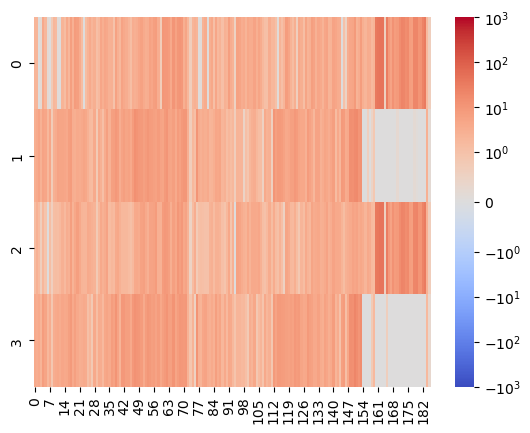

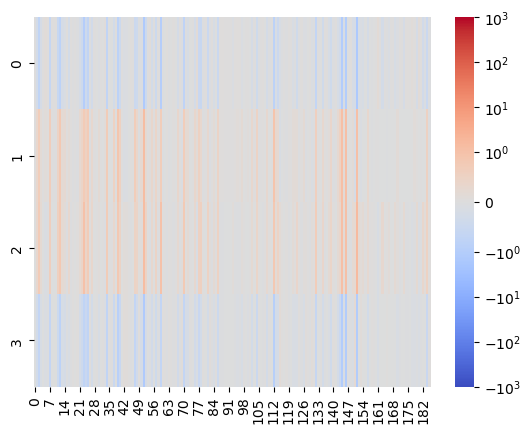

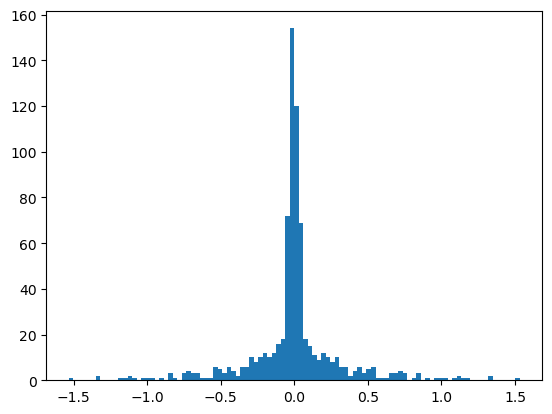

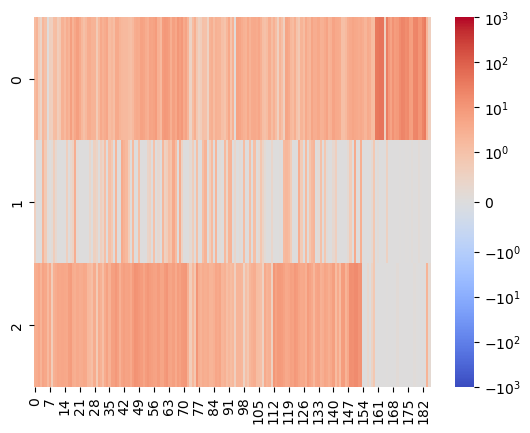

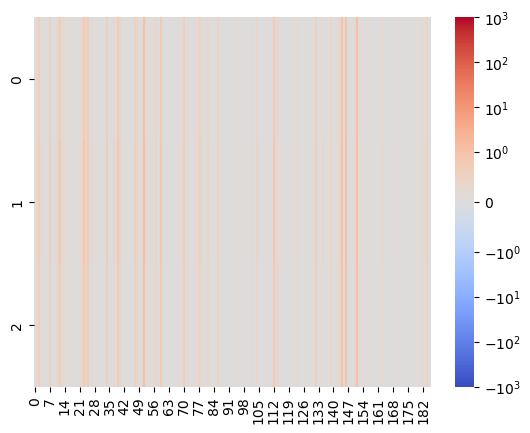

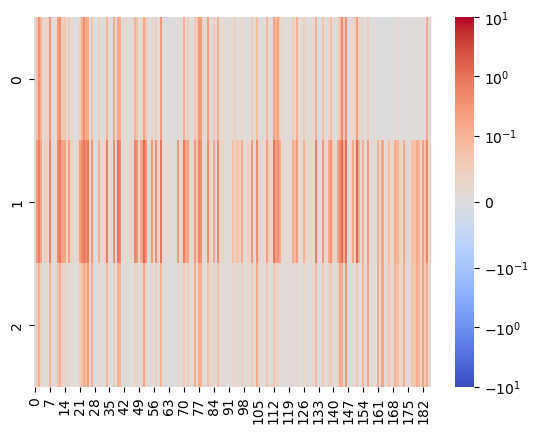

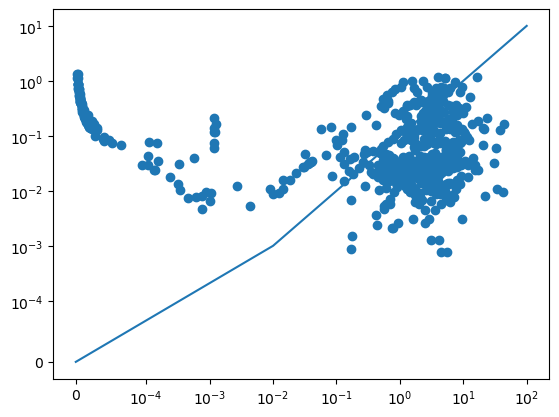

In [117]:
model_name = 'Normal'
depth_model_class, depth_model_params = sz.depth_model.NAMED_DEPTH_MODELS[model_name]
print(depth_model_class, depth_model_params)

fit2 = depth_model_class(**depth_model_params, maxiter=10000).fit(y, sz.deconvolution.pathset_to_design(sz.deconvolution.PathSet(frozenset({
    sz.deconvolution.LocalPath(0, 0),
    sz.deconvolution.LocalPath(1, 1),
    sz.deconvolution.LocalPath(0, 1),
}), n=2, m=2)))

print(fit2._aic)

fig = plt.figure()
sns.heatmap(fit2.y, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap(fit2.residual, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
plt.hist(fit2.residual.flatten(), bins=100)
# plt.plot(np.linspace(-2, 2), sp.stats.norm(loc=0, scale=fit.params['sigma'].mean()).pdf(np.linspace(-2, 2)))

fig = plt.figure()
sns.heatmap(fit2.beta, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap(fit2.stderr_beta, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap((fit2.stderr_beta) / (fit2.beta + 1), norm=mpl.colors.SymLogNorm(1e-1, vmin=-1e1, vmax=1e1), cmap='coolwarm')

fig = plt.figure()
plt.scatter(fit2.beta, fit2.stderr_beta)
xx = np.concatenate([[0], np.logspace(-2, 2)])
plt.plot(xx, xx * 0.1)
# plt.plot(xx, (xx + 1) * 0.1)
# plt.plot(xx, (xx + 1) * 0.5)
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('symlog', linthresh=1e-4)

print('max_relative_stderr:', np.where(fit2.stderr_beta > 1, fit2.stderr_beta / (np.abs(fit2.beta) + 1), -1).max())

Array(-411.0725, dtype=float32)